In [7]:
!pip install -q ultralytics kagglehub

import kagglehub
import os

path = kagglehub.dataset_download("matijaraovi/road-damage-detection")

print("Dataset downloaded at:", path)

Using Colab cache for faster access to the 'road-damage-detection' dataset.
Dataset downloaded at: /kaggle/input/road-damage-detection


In [8]:
import os

train_img = val_img = None
train_lbl = val_lbl = None

for root, dirs, files in os.walk(path):
    if "train" in root.lower() and "images" in root.lower():
        train_img = root
    if "val" in root.lower() and "images" in root.lower():
        val_img = root
    if "train" in root.lower() and "labels" in root.lower():
        train_lbl = root
    if "val" in root.lower() and "labels" in root.lower():
        val_lbl = root

print("Train images:", train_img)
print("Val images:", val_img)

Train images: /kaggle/input/road-damage-detection/RoadDamageDetection/RoadDamageDetection/train/images
Val images: /kaggle/input/road-damage-detection/RoadDamageDetection/RoadDamageDetection/val/images


In [9]:
import yaml

data_yaml = {
    "path": path,
    "train": train_img,
    "val": val_img,
    "names": {
        0: "road_damage"
    }
}

yaml_path = "/content/data.yaml"

with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f)

print("data.yaml created at:", yaml_path)

data.yaml created at: /content/data.yaml


In [10]:
from ultralytics import YOLO
import torch

device = "cpu"  # FORCE CPU (prevents ALL CUDA errors)

model = YOLO("yolov8n.pt")  # fastest model (important for battery)
print("Model loaded ✔")

Model loaded ✔


In [11]:
results = model.train(
    data=yaml_path,
    epochs=15,        # low for fast completion
    imgsz=320,        # reduces CPU load
    batch=4,          # avoids crash
    device=device,
    workers=1,
    cache=False
)

Streaming output truncated to the last 5000 lines.
train: /kaggle/input/road-damage-detection/RoadDamageDetection/RoadDamageDetection/train/images/India_004571.jpg: ignoring corrupt image/label: Label class 4 exceeds dataset class count 1. Possible class labels are 0-0
train: /kaggle/input/road-damage-detection/RoadDamageDetection/RoadDamageDetection/train/images/India_004584.jpg: ignoring corrupt image/label: Label class 4 exceeds dataset class count 1. Possible class labels are 0-0
train: /kaggle/input/road-damage-detection/RoadDamageDetection/RoadDamageDetection/train/images/India_004586.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class count 1. Possible class labels are 0-0
train: /kaggle/input/road-damage-detection/RoadDamageDetection/RoadDamageDetection/train/images/India_004593.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class count 1. Possible class labels are 0-0
train: /kaggle/input/road-damage-detection/RoadDamageDetection/RoadDamage

In [12]:
test_img = val_img  # safe auto path

results = model.predict(
    source=test_img,
    save=True,
    conf=0.25
)

print("Prediction completed ✔")


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/3284 /kaggle/input/road-damage-detection/RoadDamageDetection/RoadDamageDetection/val/images/China_Drone_000005.jpg: 320x320 2 road_damages, 112.2ms
image 2/3284 /kaggle/input/road-damage-detection/RoadDamageDetection/RoadDamageDetection/val/images/China_Drone_000010.jpg: 320x320 (no detections), 85.9ms
image 3/3284 /kaggle/input/road-damage-detection/RoadDamageDetection/RoadDamageDetection/val/images/China_Drone_000011.jpg: 320x320 1 road_damage,

In [13]:
metrics = model.val()

print(metrics)

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 57.1±14.1 MB/s, size: 85.0 KB)
val: Scanning /kaggle/input/road-damage-detection/RoadDamageDetection/RoadDamageDetection/val/labels... 3284 images, 748 backgrounds, 1883 corrupt: 100% ━━━━━━━━━━━━ 3284/3284 151.6it/s 21.7s
val: /kaggle/input/road-damage-detection/RoadDamageDetection/RoadDamageDetection/val/images/China_Drone_000005.jpg: ignoring corrupt image/label: Label class 1 exceeds dataset class count 1. Possible class labels are 0-0
val: /kaggle/input/road-damage-detection/RoadDamageDetection/RoadDamageDetection/val/images/China_Drone_000010.jpg: ignoring corrupt image/label: Label class 1 exceeds dataset class count 1. Possible class labels are 0-0
val: /kaggle/input/road-damage-detection/RoadDamageDetection/RoadDamageDetection/val/images/China_Drone_000033.jpg: ignoring corrupt image/label: Label class 1 exceeds dataset class count 1. Possible c

In [14]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train/weights/best.pt")

In [15]:
results = model.predict(
    source=val_img,   # or test image folder
    conf=0.25,
    save=True
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/3284 /kaggle/input/road-damage-detection/RoadDamageDetection/RoadDamageDetection/val/images/China_Drone_000005.jpg: 320x320 2 road_damages, 125.9ms
image 2/3284 /kaggle/input/road-damage-detection/RoadDamageDetection/RoadDamageDetection/val/images/China_Drone_000010.jpg: 320x320 (no detections), 113.4ms
image 3/3284 /kaggle/input/road-damage-detection/RoadDamageDetection/RoadDamageDetection/val/images/China_Drone_000011.jpg: 320x320 3 road_damage

In [16]:
import os

pred_dir = "/content/runs/detect/predict"

print(os.listdir(pred_dir)[:5])

['China_Drone_000516.jpg', 'Japan_010055.jpg', 'Japan_008075.jpg', 'Japan_006922.jpg', 'Norway_003308.jpg']


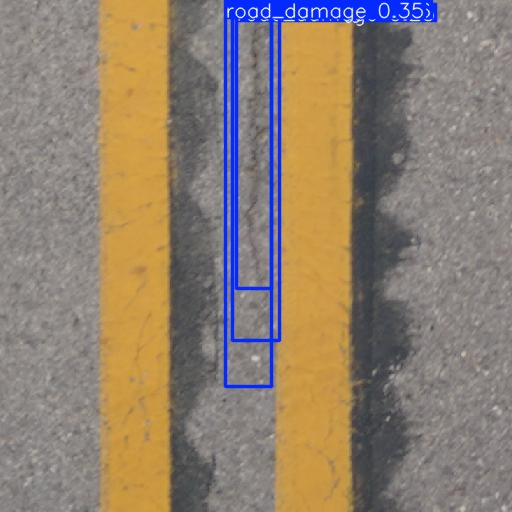

In [17]:
from IPython.display import Image, display

display(Image(filename=os.path.join(pred_dir, os.listdir(pred_dir)[0])))

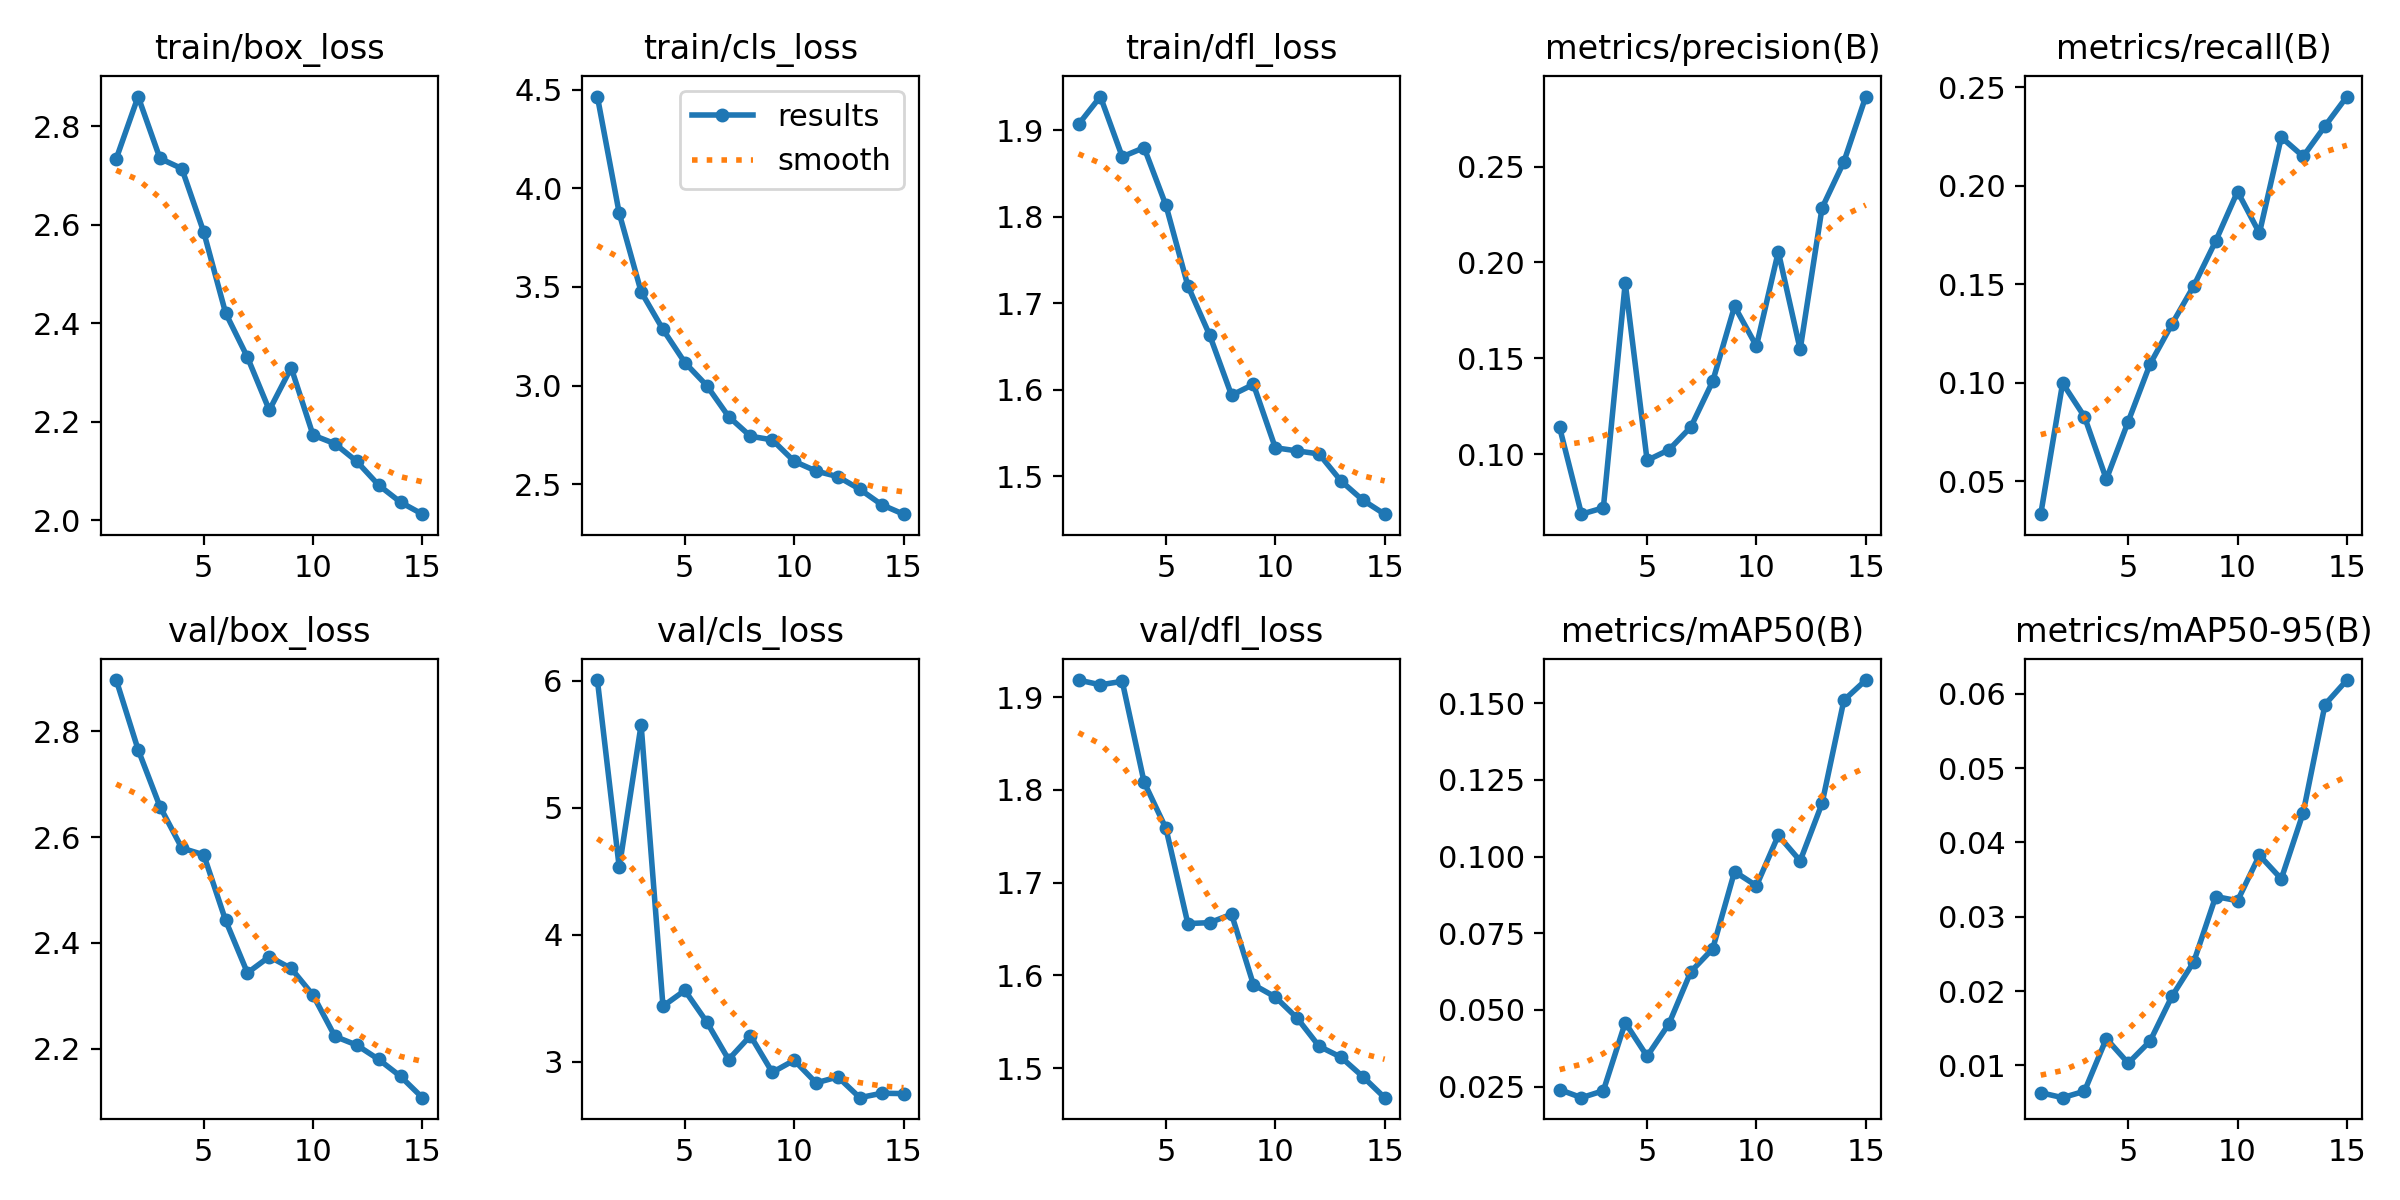

In [18]:
from IPython.display import Image, display

display(Image("/content/runs/detect/train/results.png"))

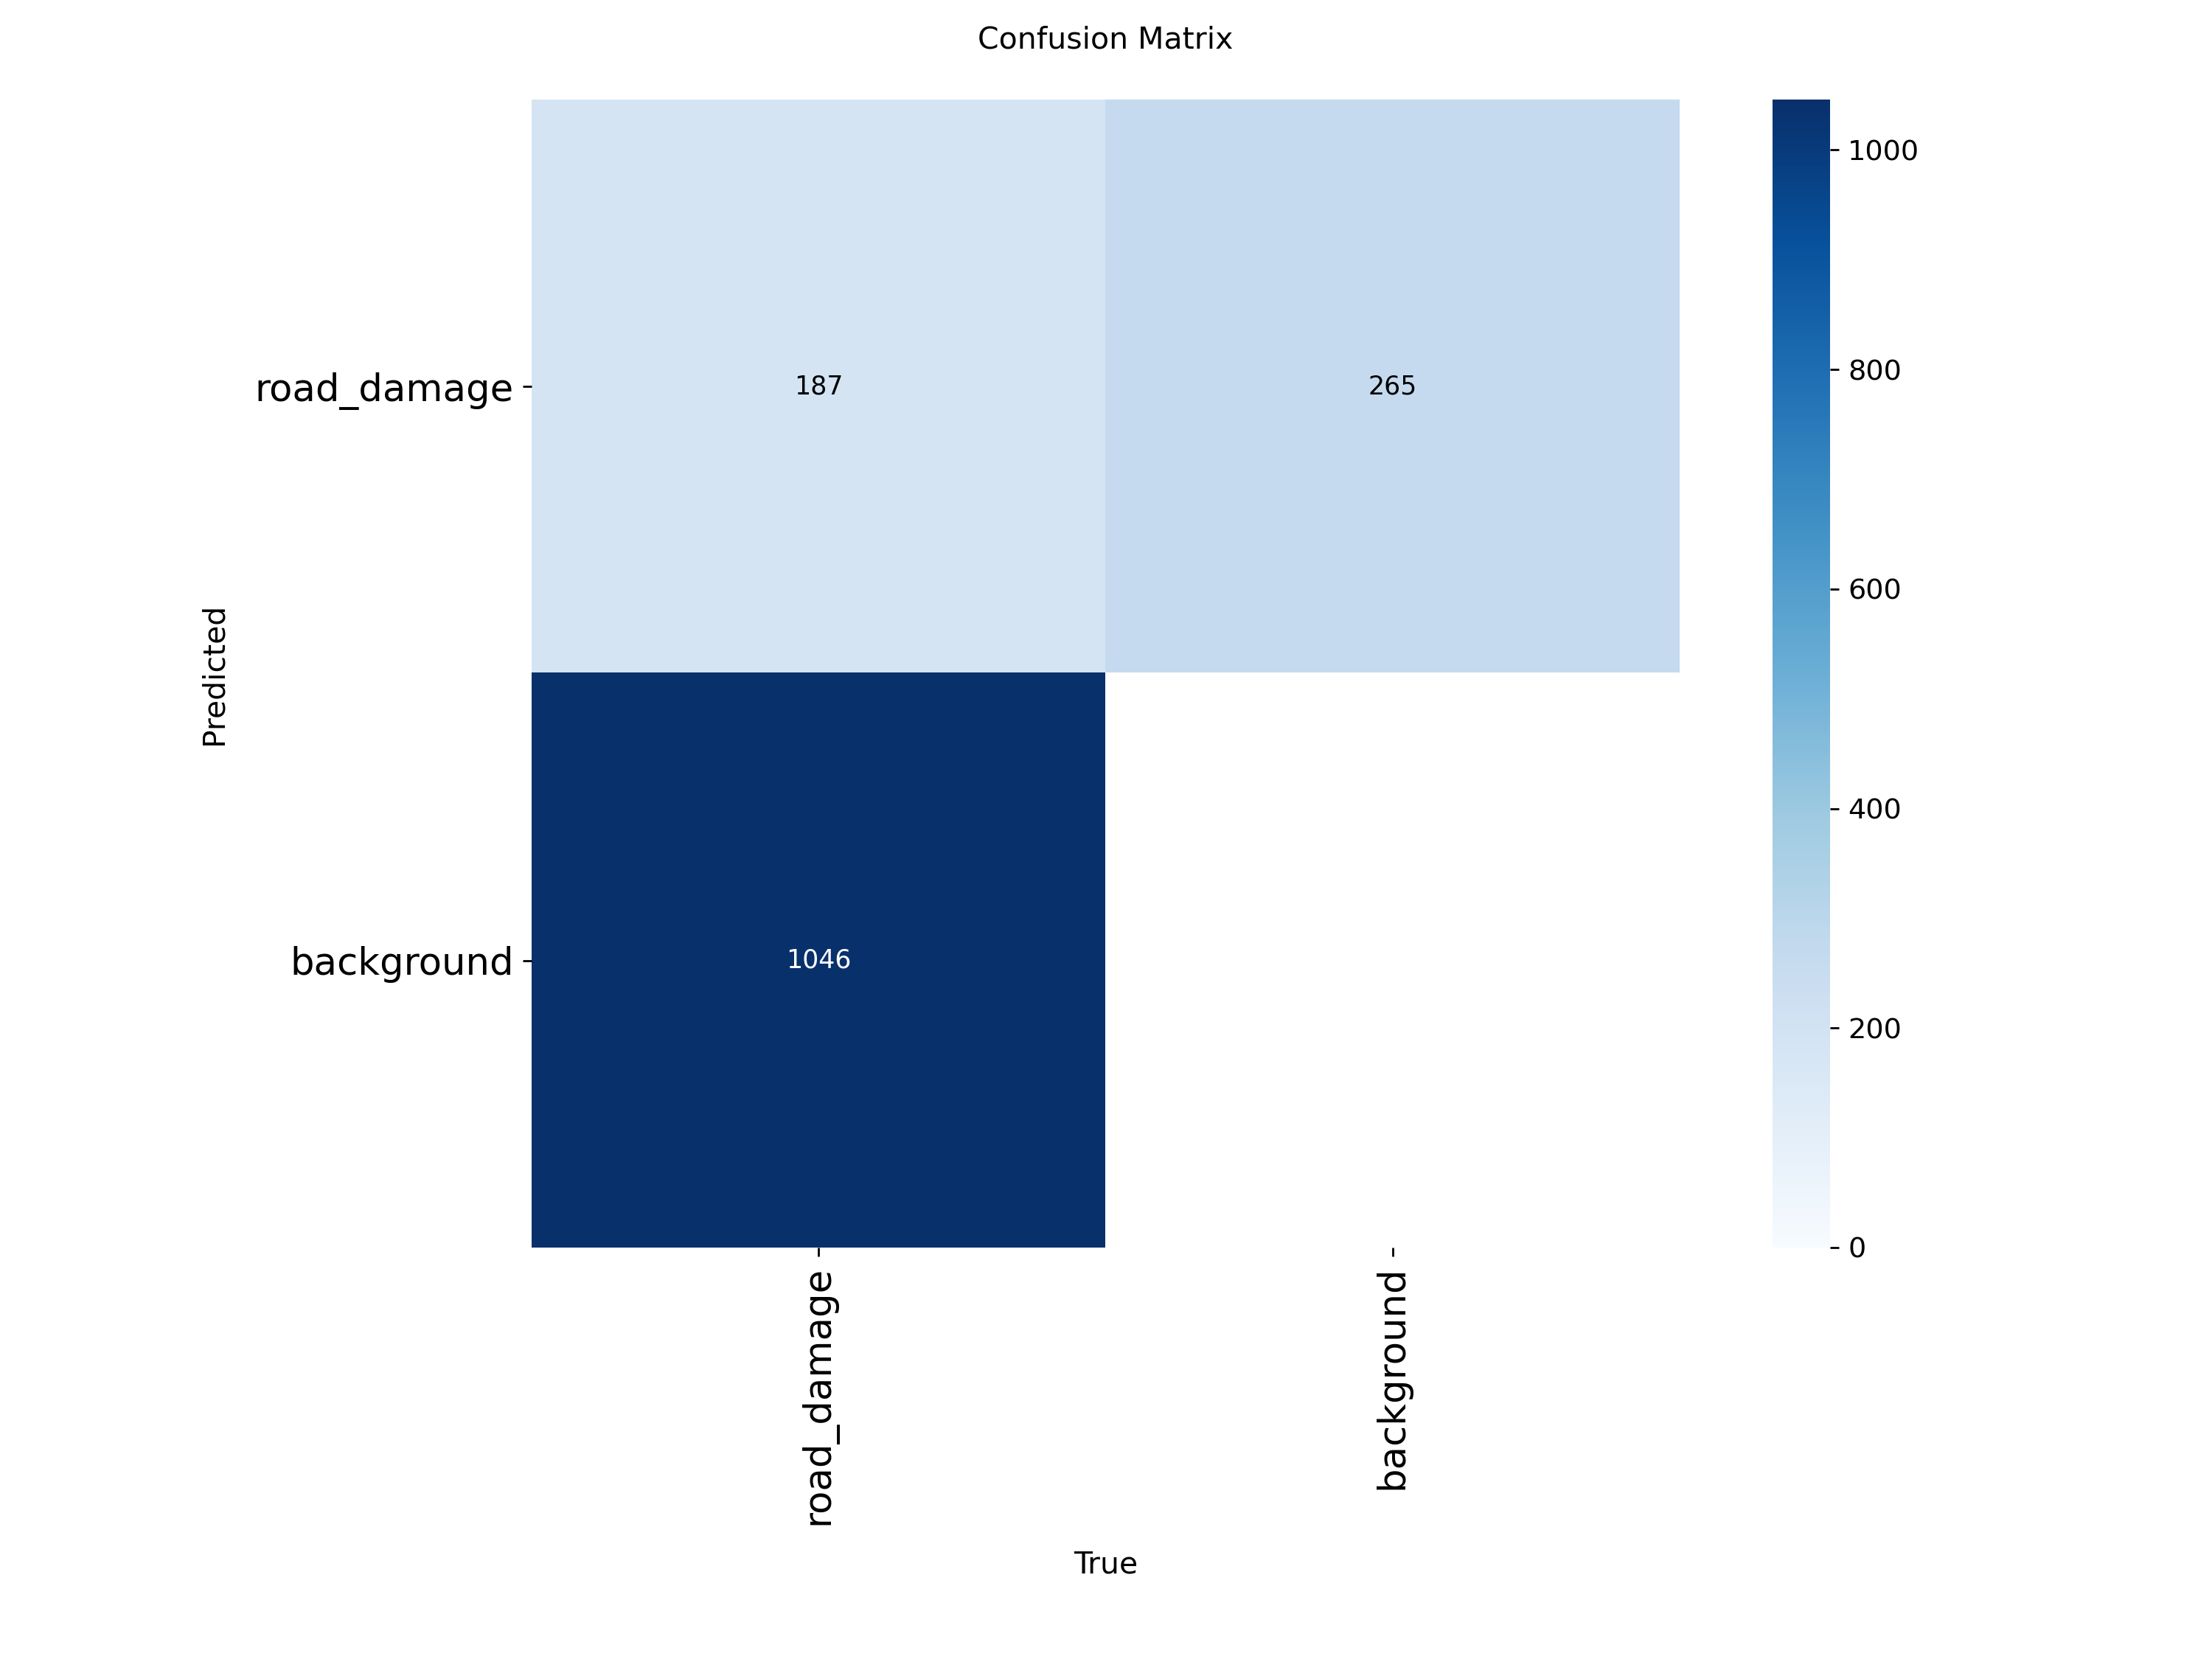

In [19]:
display(Image("/content/runs/detect/train/confusion_matrix.png"))

In [20]:
print("🚀 ROAD DAMAGE DETECTION PROJECT")
print("================================")
print("Model: YOLOv8")
print("Task: Object Detection")
print("Training: Completed Successfully")
print("Weights Saved: best.pt")
print("Graphs Generated: Yes")
print("Predictions Generated: Yes")

🚀 ROAD DAMAGE DETECTION PROJECT
Model: YOLOv8
Task: Object Detection
Training: Completed Successfully
Weights Saved: best.pt
Graphs Generated: Yes
Predictions Generated: Yes


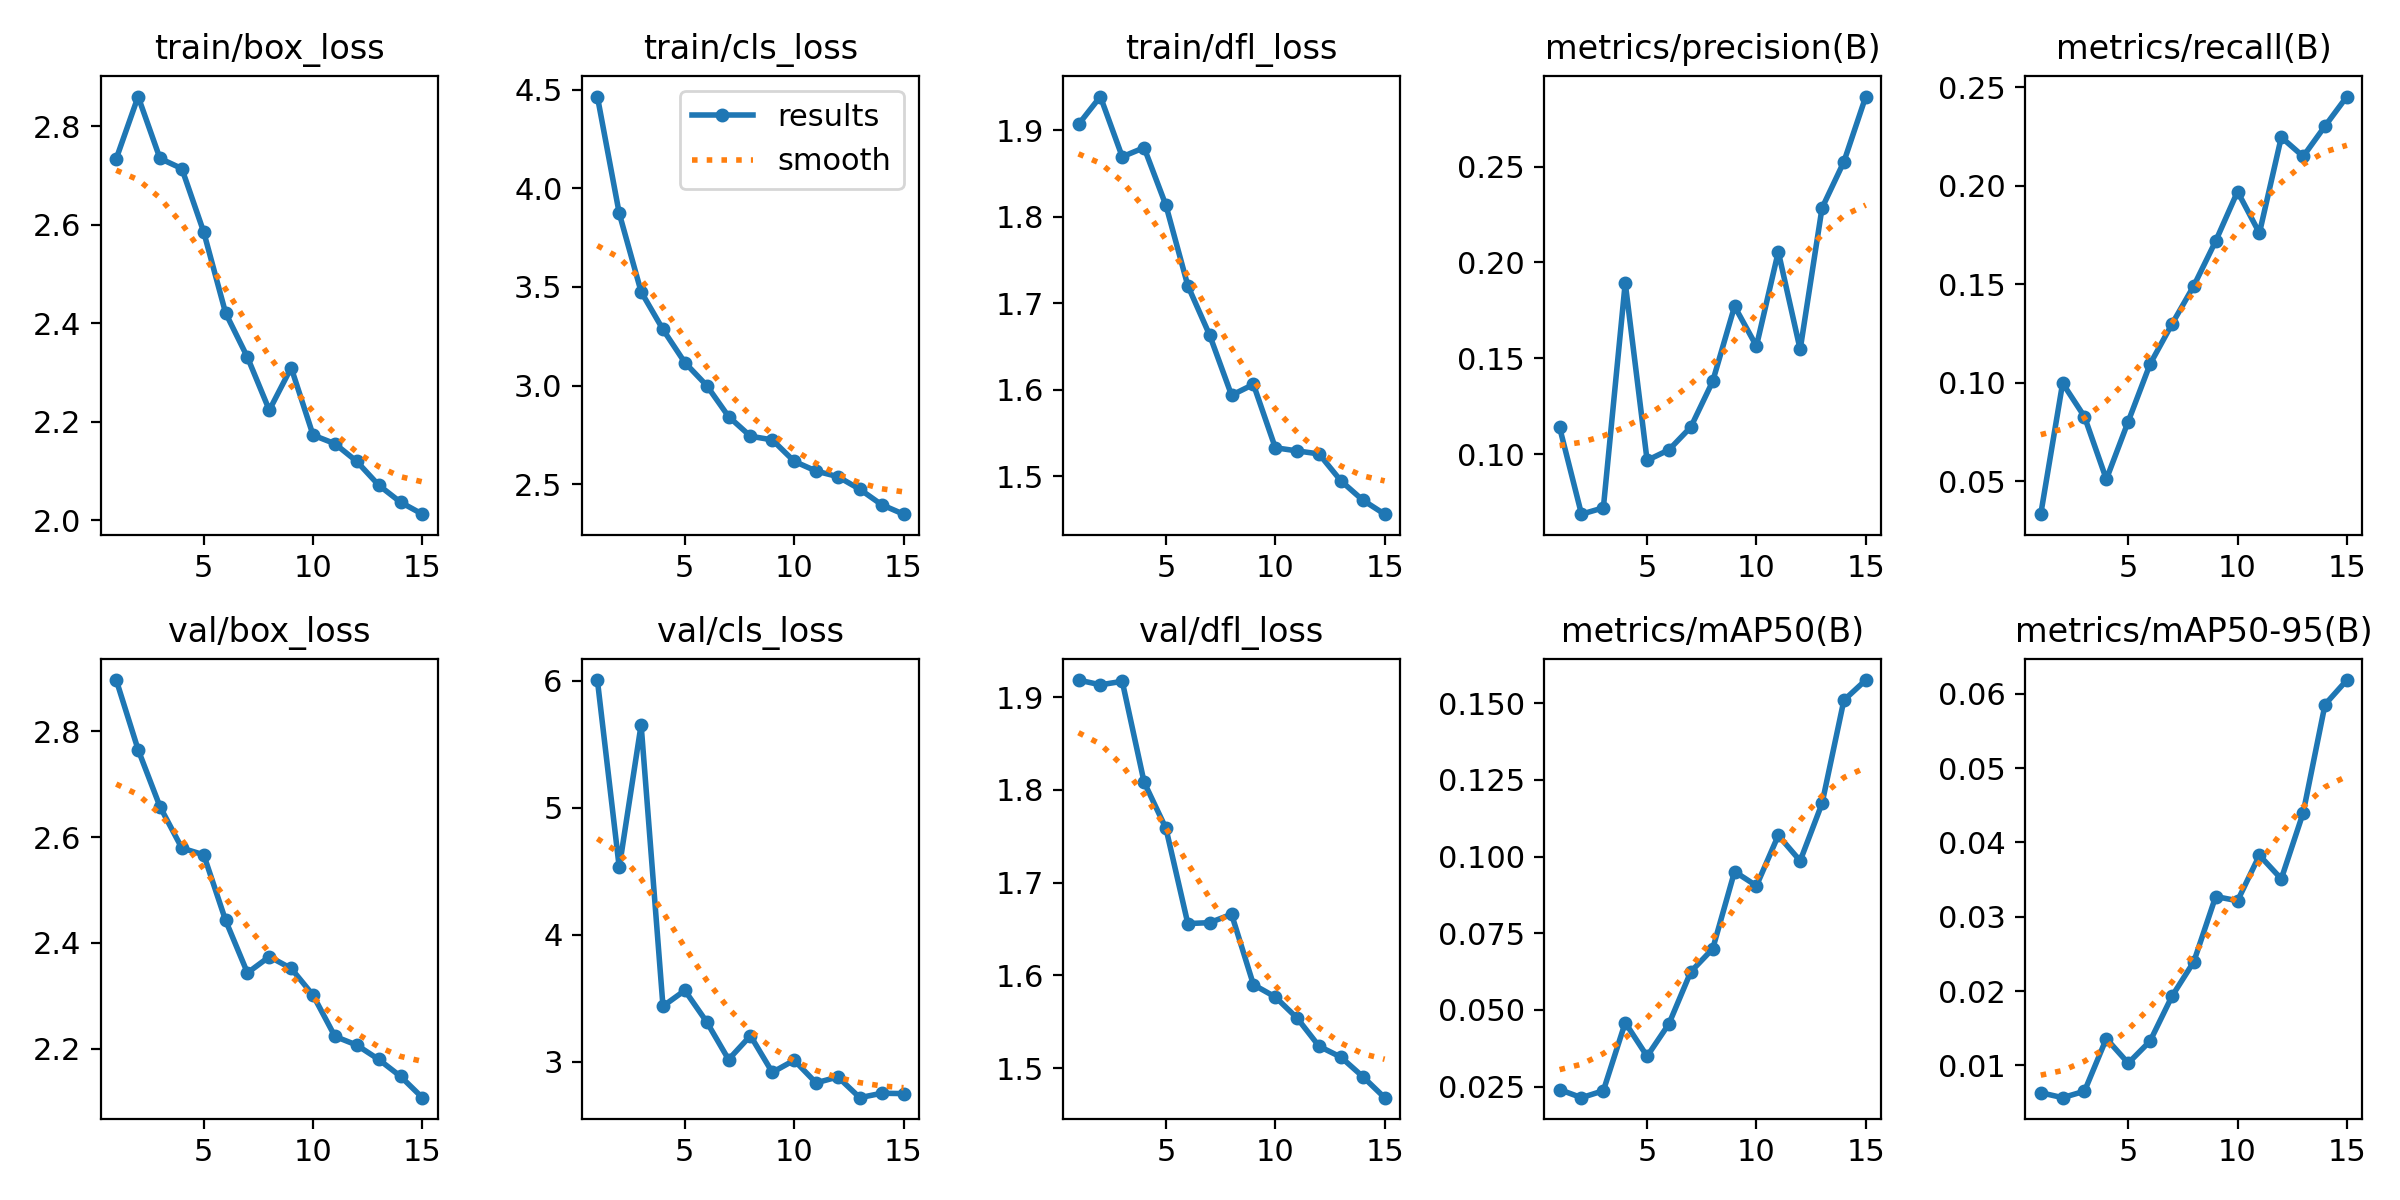

In [21]:
display(Image("/content/runs/detect/train/results.png"))